In [1]:
# Optional: ensure a compatible Hugging Face stack in this kernel.
# Safe to re-run.

import os
import sys
import subprocess
import importlib.metadata as importlib_metadata

def _version_or_none(pkg_name):
    try:
        return importlib_metadata.version(pkg_name)
    except importlib_metadata.PackageNotFoundError:
        return None

hub_version = _version_or_none("huggingface-hub")
tfm_version = _version_or_none("transformers")

need_install = (
    tfm_version is None
    or hub_version is None
    or hub_version.startswith("1.")
)

if need_install:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "transformers>=4.38,<5",
        "huggingface-hub>=0.19.3,<1.0",
        "safetensors>=0.4.0",
    ])

# Prevent transformers from touching TensorFlow in this environment.
os.environ["USE_TF"] = "0"
os.environ["TRANSFORMERS_NO_TF"] = "1"


In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import torch
from pytorch_ood.detector import Mahalanobis
from pytorch_ood.utils import OODMetrics
from torch.utils.data import DataLoader
from transformers import AutoModel

# Make the helper module importable from the notebook directory.
NOTEBOOK_DIR = Path.cwd().parent
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.append(str(NOTEBOOK_DIR))

from utils.ood_datasets import (
    MRIDataset,
    ComposeImageTransforms,
    EnsureChannels,
    ResizeImageOrVolume,
    NormalizePerChannel,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cuda


In [3]:
# DINOv2-base is the closest Hugging Face DINOv2 size to a ViT-B / medSAM-vit_b backbone.
DINO_MODEL_NAME = "facebook/dinov2-base"
DINO_IMAGE_SIZE = 224
DINO_PATCH_SIZE = 14
DINO_EMBED_DIM = 768

dinov2 = AutoModel.from_pretrained(DINO_MODEL_NAME).to(device).eval()
print("Loaded:", DINO_MODEL_NAME)

DINO_MEAN = (0.485, 0.456, 0.406)
DINO_STD = (0.229, 0.224, 0.225)

# Model-specific input requirements live in this transform block.
dino_model_transform = ComposeImageTransforms([
    EnsureChannels(3),
    ResizeImageOrVolume((DINO_IMAGE_SIZE, DINO_IMAGE_SIZE)),
    NormalizePerChannel(mean=DINO_MEAN, std=DINO_STD),
])

@torch.no_grad()
def extract_dinov2_features(x: torch.Tensor):
    """
    x: [B, C, H, W], already prepared for DINOv2 by the dataset model_transform.

    Returns:
      cls_features:   [B, 768]
      patch_features: [B, 768, grid, grid]
      patch_tokens:   [B, grid*grid, 768]
    """
    x = x.to(device)
    outputs = dinov2(pixel_values=x)
    hidden = outputs.last_hidden_state
    cls_features = hidden[:, 0]
    patch_tokens = hidden[:, 1:]

    grid = DINO_IMAGE_SIZE // DINO_PATCH_SIZE
    patch_features = patch_tokens.transpose(1, 2).reshape(-1, DINO_EMBED_DIM, grid, grid)
    return cls_features, patch_features, patch_tokens

@torch.no_grad()
def get_embedding(batch_images: torch.Tensor) -> torch.Tensor:
    cls_features, _, _ = extract_dinov2_features(batch_images)
    return cls_features


def denormalize_for_display(x: torch.Tensor) -> torch.Tensor:
    """Undo DINO/ImageNet normalization for visualization."""
    mean = torch.tensor(DINO_MEAN, dtype=x.dtype, device=x.device).view(-1, 1, 1)
    std = torch.tensor(DINO_STD, dtype=x.dtype, device=x.device).view(-1, 1, 1)
    x = x * std + mean
    return x.clamp(0.0, 1.0)


/home/jovyan/.local/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Loaded: facebook/dinov2-base


In [4]:
datasets_path = "../datasets/"
prep_datasets = "/prep_datasets"
ID_path = datasets_path + prep_datasets + "/MnM_splits/vendor_split_ed_es/Philips"
OOD_path = datasets_path + prep_datasets + "/MnM_splits/vendor_split_ed_es/GE"

id_train_dataset = MRIDataset(
    root=ID_path,
    output_mode="2d",
    slice_strategy="middle_3",
    slice_axis=2,
    channels=1,                # modality output stays grayscale
    label=0,
    split="train",
    seed=42,
    train_ratio=0.7,
    return_metadata=False,
    model_transform=dino_model_transform,
)

id_val_dataset = MRIDataset(
    root=ID_path,
    output_mode="2d",
    slice_strategy="middle_3",
    slice_axis=2,
    channels=1,
    label=0,
    split="test",
    seed=42,
    train_ratio=0.7,
    return_metadata=False,
    model_transform=dino_model_transform,
)

ood_dataset = MRIDataset(
    root=OOD_path,
    output_mode="2d",
    slice_strategy="middle_3",
    slice_axis=2,
    channels=1,
    label=-1,
    split="all",
    seed=42,
    return_metadata=False,
    model_transform=dino_model_transform,
)

id_train_loader = DataLoader(id_train_dataset, batch_size=4, shuffle=True, num_workers=0)
id_val_loader = DataLoader(id_val_dataset, batch_size=4, shuffle=True, num_workers=0)
ood_loader = DataLoader(ood_dataset, batch_size=4, shuffle=True, num_workers=0)

print("ID train samples:", len(id_train_dataset))
print("ID val samples:", len(id_val_dataset))
print("OOD samples:", len(ood_dataset))


ID train samples: 525
ID val samples: 225
OOD samples: 450


In [5]:
id_batch = next(iter(id_val_loader))
ood_batch = next(iter(ood_loader))

imgs = id_batch["image"]
labels = id_batch["label"]
imgs_ood = ood_batch["image"]
labels_ood = ood_batch["label"]

print("ID batch:", imgs.shape, labels.shape)
print("OOD batch:", imgs_ood.shape, labels_ood.shape)
print("ID value range:", float(imgs.min()), float(imgs.max()))
print("OOD value range:", float(imgs_ood.min()), float(imgs_ood.max()))


ID batch: torch.Size([4, 3, 224, 224]) torch.Size([4])
OOD batch: torch.Size([4, 3, 224, 224]) torch.Size([4])
ID value range: -2.1179039478302 2.640000104904175
OOD value range: -2.1179039478302 2.640000104904175


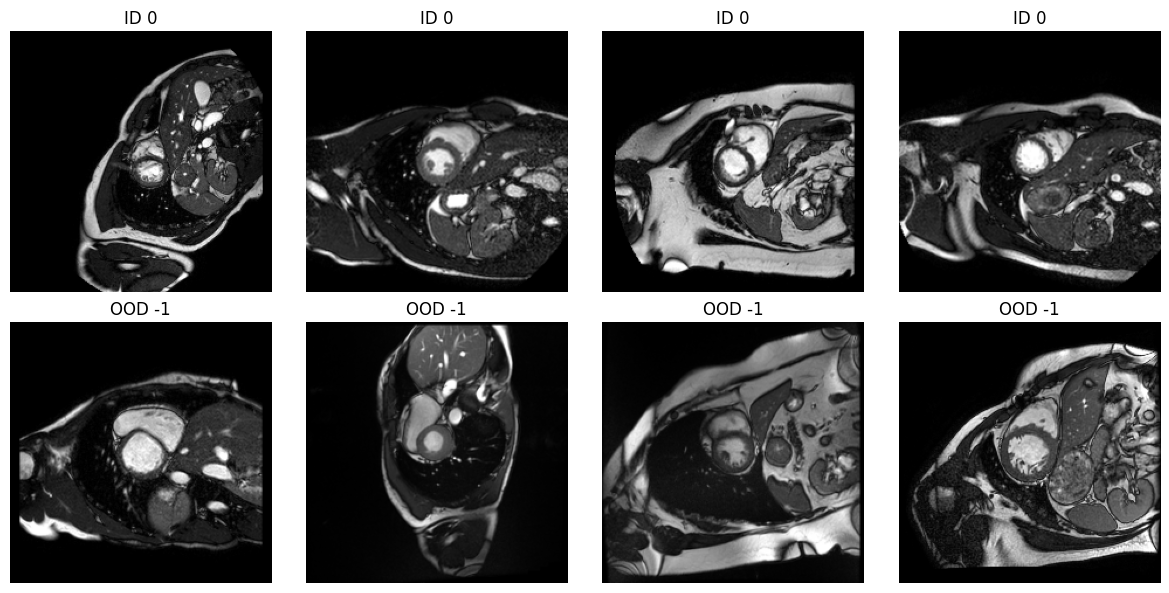

In [6]:
id_batch = next(iter(id_train_loader))
ood_batch = next(iter(ood_loader))

imgs = denormalize_for_display(id_batch["image"])
labels = id_batch["label"]
imgs_ood = denormalize_for_display(ood_batch["image"])
labels_ood = ood_batch["label"]

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i in range(4):
    img = imgs[i].permute(1, 2, 0).cpu().numpy()
    img_ood = imgs_ood[i].permute(1, 2, 0).cpu().numpy()

    axes[0, i].imshow(img)
    axes[0, i].set_title(f"ID {int(labels[i])}")
    axes[0, i].axis("off")

    axes[1, i].imshow(img_ood)
    axes[1, i].set_title(f"OOD {int(labels_ood[i])}")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()


In [20]:
# Stage 1: extract DINOv2 embeddings from the ID data and fit Mahalanobis

feats_list = []
labels_list = []

dinov2.eval()
with torch.no_grad():
    for batch in id_train_loader:
        imgs = batch["image"].to(device)
        y = batch["label"].to(device)

        z = get_embedding(imgs)   # [B, 768] CLS token
        feats_list.append(z)
        labels_list.append(y)

Z_id = torch.cat(feats_list, dim=0)
Y_id = torch.cat(labels_list, dim=0)

print("Z_id:", Z_id.shape)
print("Y_id:", Y_id.shape, "unique labels:", torch.unique(Y_id))

detector = Mahalanobis(model=None)
detector.fit_features(Z_id, Y_id)


No device given. Will use 'cuda:0'.


Z_id: torch.Size([525, 768])
Y_id: torch.Size([525]) unique labels: tensor([0], device='cuda:0')


In [28]:
path_to_save="../feature_space_inspection/"

torch.save(Z_id.detach().cpu(), path_to_save + "DINOv2_MnM")

In [22]:
mean = Z_id.mean()
std = Z_id.std()
min_val = Z_id.min()
max_val = Z_id.max()


print("ID stats:")
print("mean:", mean)
print("std:", std)
print("min:", min_val)
print("max:", max_val)

ID stats:
mean: tensor(-0.0288, device='cuda:0')
std: tensor(1.6998, device='cuda:0')
min: tensor(-12.6308, device='cuda:0')
max: tensor(8.8773, device='cuda:0')


In [7]:
# Predict on ID validation and OOD datasets

feats_list_id_val = []
feats_list_ood = []

with torch.no_grad():
    for batch in id_val_loader:
        imgs = batch["image"].to(device)
        z = get_embedding(imgs)
        feats_list_id_val.append(z)

    for batch in ood_loader:
        imgs = batch["image"].to(device)
        z = get_embedding(imgs)
        feats_list_ood.append(z)

Z_id_val = torch.cat(feats_list_id_val, dim=0)
Z_ood = torch.cat(feats_list_ood, dim=0)

path_to_save="../feature_space_inspection/"
torch.save(Z_ood.detach().cpu(), path_to_save + "DINOv2_MnM_ood")

scores_id_val = detector.predict_features(Z_id_val)
scores_ood = detector.predict_features(Z_ood)

print("Z_ood:", Z_ood.shape)
print("scores_id:", scores_id_val.shape)
print("scores_ood:", scores_ood.shape)


NameError: name 'detector' is not defined

In [24]:
mean = Z_id_val.mean()
std = Z_id_val.std()
min_val = Z_id_val.min()
max_val = Z_id_val.max()


print("ID stats:")
print("mean:", mean)
print("std:", std)
print("min:", min_val)
print("max:", max_val)

ID stats:
mean: tensor(-0.0292, device='cuda:0')
std: tensor(1.6911, device='cuda:0')
min: tensor(-12.7591, device='cuda:0')
max: tensor(8.2790, device='cuda:0')


In [25]:
mean = Z_ood.mean()
std = Z_ood.std()
min_val = Z_ood.min()
max_val = Z_ood.max()


print("ID stats:")
print("mean:", mean)
print("std:", std)
print("min:", min_val)
print("max:", max_val)

ID stats:
mean: tensor(-0.0352, device='cuda:0')
std: tensor(1.6517, device='cuda:0')
min: tensor(-11.4010, device='cuda:0')
max: tensor(9.0810, device='cuda:0')


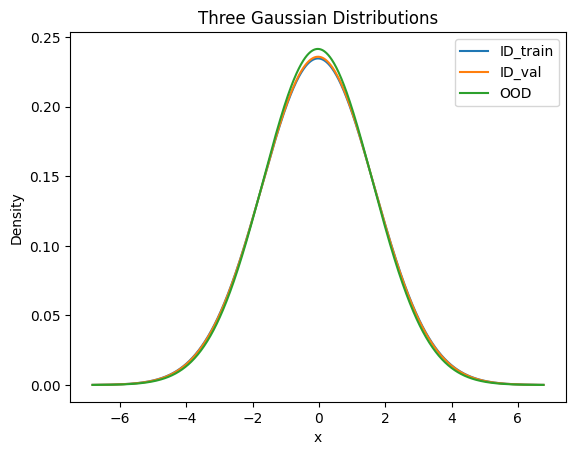

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# Example means and stds (replace with yours)
mu1, sigma1 = -0.0288, 1.6998
mu2, sigma2 = -0.0292, 1.6911
mu3, sigma3 = -0.0352, 1.6517

# Shared x-axis range (important!)
x_min = min(mu1 - 4*sigma1, mu2 - 4*sigma2, mu3 - 4*sigma3)
x_max = max(mu1 + 4*sigma1, mu2 + 4*sigma2, mu3 + 4*sigma3)
x = np.linspace(x_min, x_max, 1000)

def gaussian(x, mu, sigma):
    return (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-((x - mu)**2) / (2 * sigma**2))

# Compute curves
y1 = gaussian(x, mu1, sigma1)
y2 = gaussian(x, mu2, sigma2)
y3 = gaussian(x, mu3, sigma3)

# Plot
plt.plot(x, y1, label="ID_train")
plt.plot(x, y2, label="ID_val")
plt.plot(x, y3, label="OOD")

plt.title("Three Gaussian Distributions")
plt.xlabel("x")
plt.ylabel("Density")
plt.legend()
plt.show()

In [26]:
# Evaluate OOD metrics

y_id_val=torch.zeros(len(scores_id_val), dtype=torch.long)
y_ood=-torch.ones(len(scores_ood), dtype=torch.long)
img_scores = torch.cat([scores_id_val, scores_ood], dim=0)
img_labels = torch.cat([
    y_id_val,
    y_ood,
], dim=0)

metrics = OODMetrics()
metrics.update(img_scores, img_labels)
img_result = metrics.compute()

print("Image-level metrics:")
print(img_result)


Image-level metrics:
{'AUROC': 0.4057876467704773, 'AUTC': 0.5273134708404541, 'AUPR-IN': 0.4736713767051697, 'AUPR-OUT': 0.6596865653991699, 'FPR95TPR': 1.0}


In [10]:
print("ID stats:")
print("mean:", scores_id_val.mean().item())
print("std:", scores_id_val.std().item())
print("min:", scores_id_val.min().item())
print("max:", scores_id_val.max().item())


ID stats:
mean: -6636.5068359375
std: 38377.9453125
min: -143467.328125
max: 106203.9375


In [11]:
print("OOD stats:")
print("mean:", scores_ood.mean().item())
print("std:", scores_ood.std().item())
print("min:", scores_ood.min().item())
print("max:", scores_ood.max().item())
print("median:", scores_ood.median().item())


OOD stats:
mean: 15274.990234375
std: 112714.1640625
min: -1303339.5
max: 300818.84375
median: 17837.015625


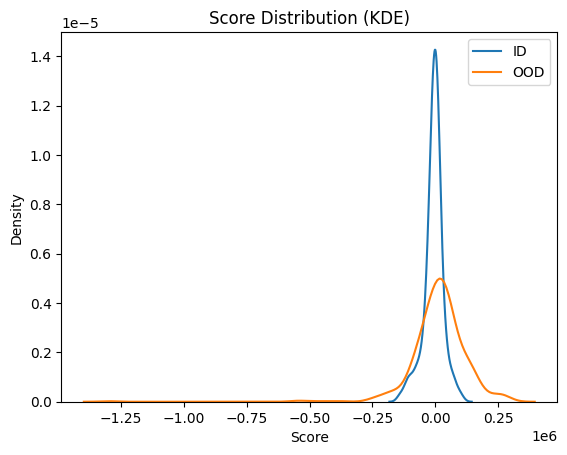

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

scores_id_np = scores_id_val.detach().cpu().numpy()
scores_ood_np = scores_ood.detach().cpu().numpy()

sns.kdeplot(scores_id_np, label="ID", fill=False)
sns.kdeplot(scores_ood_np, label="OOD", fill=False)

plt.title("Score Distribution (KDE)")
plt.xlabel("Score")
plt.ylabel("Density")
plt.legend()
plt.show()


In [14]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# -----------------------------
# 1) Convert features to numpy
# -----------------------------
X_id = Z_id_val.detach().cpu().numpy()      # [N_id, C]
y_id = y_id_val.detach().cpu().numpy()      # [N_id]

X_ood = Z_ood.detach().cpu().numpy()    # [N_ood, C]

# If you have OOD labels, use them here.
# Example:
y_ood = y_ood.detach().cpu().numpy()

# If you do NOT have OOD labels, assign a placeholder label.
# This is only for plotting/coloring if needed.
# y_ood = np.full(shape=(X_ood.shape[0],), fill_value=-1)

# -----------------------------------------
# 2) Concatenate so t-SNE sees both together
# -----------------------------------------
X_all = np.concatenate([X_id, X_ood], axis=0)
y_all = np.concatenate([y_id, y_ood], axis=0)

# Keep track of domain: ID vs OOD
domain_all = np.concatenate([
    np.zeros(X_id.shape[0], dtype=int),   # 0 = ID
    np.ones(X_ood.shape[0], dtype=int),   # 1 = OOD
])

# -----------------------------
# 3) Optional PCA before t-SNE
# -----------------------------
n_pca = min(50, X_all.shape[1], X_all.shape[0])
X_reduced = PCA(n_components=n_pca, random_state=42).fit_transform(X_all)

# -----------------------------
# 4) Run t-SNE
# -----------------------------
X_tsne = TSNE(
    n_components=2,
    perplexity=30,
    init="pca",
    learning_rate="auto",
    random_state=42,
).fit_transform(X_reduced)

# Split back
X_tsne_id = X_tsne[domain_all == 0]
X_tsne_ood = X_tsne[domain_all == 1]

y_id_plot = y_all[domain_all == 0]
y_ood_plot = y_all[domain_all == 1]

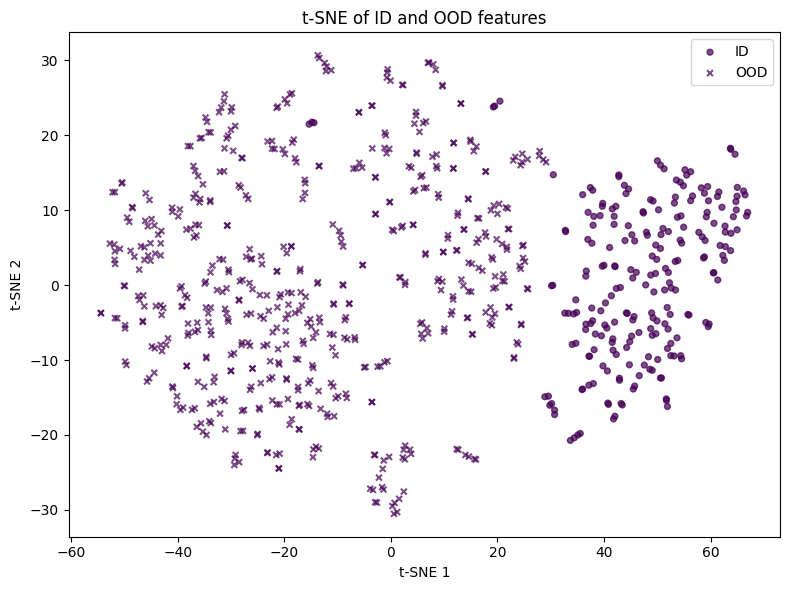

In [15]:
plt.figure(figsize=(8, 6))

# ID points
scatter_id = plt.scatter(
    X_tsne_id[:, 0],
    X_tsne_id[:, 1],
    c=y_id_plot,
    alpha=0.7,
    s=18,
    label="ID"
)

# OOD points
scatter_ood = plt.scatter(
    X_tsne_ood[:, 0],
    X_tsne_ood[:, 1],
    c=y_ood_plot,
    alpha=0.7,
    s=18,
    marker="x",
    label="OOD"
)

plt.title("t-SNE of ID and OOD features")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
plt.hist(scores_ood.detach().cpu().numpy(), bins=200)
plt.title("OOD score distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()
